In [8]:
import sys
import os

sys.path.append(os.path.abspath(".."))

# Exploratory Data Analysis (EDA)

## Objective

The objective of this analysis is to explore historical insurance claims data from AlphaCare Insurance Solutions (ACIS) in order to understand patterns in risk, profitability, claims behavior, and customer segmentation.

This notebook investigates:

- Portfolio loss ratio
- Claim distributions
- Geographic risk differences
- Vehicle-related claim patterns
- Relationships between premiums and claims
- Data quality and outlier behavior

In [9]:
df = pd.read_csv("../data/raw/insurance_data.csv")

df.head()

,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,...,Claimed,ClaimAmount,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,...,False,0.0,2346,0.0,Comprehensive,Lifan,620,32238,10002,2024-05-10
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,...,True,9883.0,2334,9883.0,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,...,False,0.0,1697,0.0,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,...,True,12134.0,2370,12134.0,Comprehensive,Toyota,Corolla,27036,40005,2025-03-17
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,...,False,0.0,2582,0.0,Comprehensive,Toyota,RAV4,58348,50002,2024-11-10


## Dataset Overview

The dataset contains information about:

- Insurance policies
- Customers
- Vehicle characteristics
- Premium payments
- Insurance claims
- Geographic information

The analysis focuses on two important business metrics:

### Loss Ratio

Loss Ratio = TotalClaims / TotalPremium

This metric measures portfolio profitability and risk exposure.

### Margin
Margin = TotalPremium − TotalClaims

This metric estimates the profit contribution per policy.

In [10]:
summarize_data(df)

NameError: name 'summarize_data' is not defined

## Data Quality Assessment

This section evaluates:

- Missing values
- Data types
- Numerical distributions
- Potential inconsistencies

Understanding data quality is essential before performing statistical analysis and predictive modeling.

In [11]:
check_missing(df)

NameError: name 'check_missing' is not defined

## Insight: Distribution of Claims

The distribution of TotalClaims is highly right-skewed, indicating that most policies generate relatively small claims while a smaller subset contributes extremely large claim amounts.

This behavior is common in insurance datasets and highlights the importance of outlier analysis and risk segmentation.

In [12]:
calculate_loss_ratio(df)

NameError: name 'calculate_loss_ratio' is not defined

## Insight: Premium Outliers

The boxplot reveals several premium outliers, suggesting that some policyholders are associated with significantly higher insured values or elevated risk profiles.

These observations may require specialized pricing strategies or further investigation.

In [ ]:
plot_histogram(df, "TotalClaims")

## Insight: Geographic Risk Differences

Claim patterns vary across provinces, suggesting that geographic location influences insurance risk.

Possible contributing factors include:

- Traffic density
- Crime rates
- Road infrastructure
- Regional driving behavior

These findings support the potential use of province-based pricing adjustments.

In [13]:
plot_boxplot(df, "TotalPremium")

NameError: name 'plot_boxplot' is not defined

## Insight: Relationship Between Premiums and Claims

The scatter plot comparing TotalPremium and TotalClaims indicates a positive relationship between premiums and claims.

Higher-risk policies tend to have both:

- Higher premiums
- Higher claim amounts

This suggests that current pricing strategies partially reflect underlying policy risk.

In [14]:
numeric_cols = [
    "TotalPremium",
    "TotalClaims",
    "CustomValueEstimate",
    "Kilowatts",
    "Cylinders"
]

correlation_heatmap(df, numeric_cols)

NameError: name 'correlation_heatmap' is not defined

## Conclusion

The exploratory analysis identified:

- Significant claim variability
- Geographic differences in risk
- Financial outliers in claims and premiums
- Relationships between premium pricing and claim severity

These findings establish a strong foundation for:

- Hypothesis testing
- Predictive modeling
- Risk-based pricing optimization

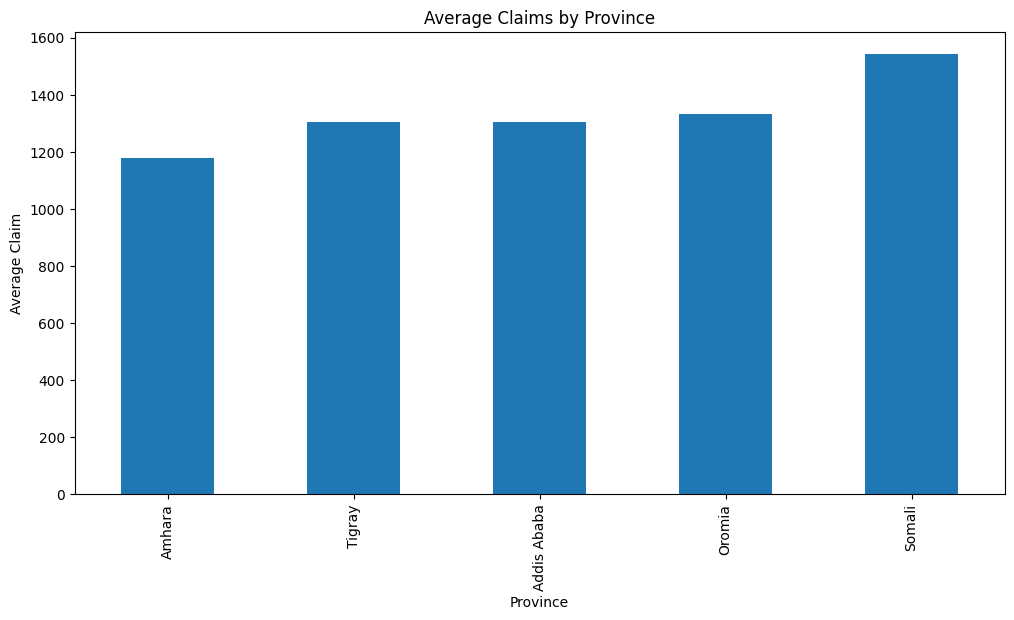

In [15]:
province_claims = (
    df.groupby("Province")["TotalClaims"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(12,6))

province_claims.plot(kind="bar")

plt.title("Average Claims by Province")
plt.ylabel("Average Claim")

plt.show()

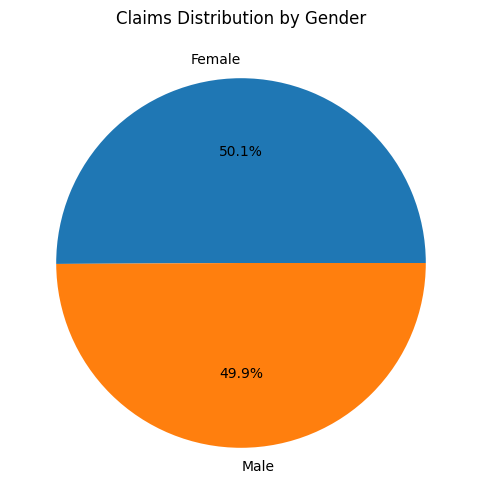

In [16]:
gender_claims = df.groupby("Gender")["TotalClaims"].mean()

plt.figure(figsize=(6,6))

gender_claims.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Claims Distribution by Gender")
plt.ylabel("")

plt.show()

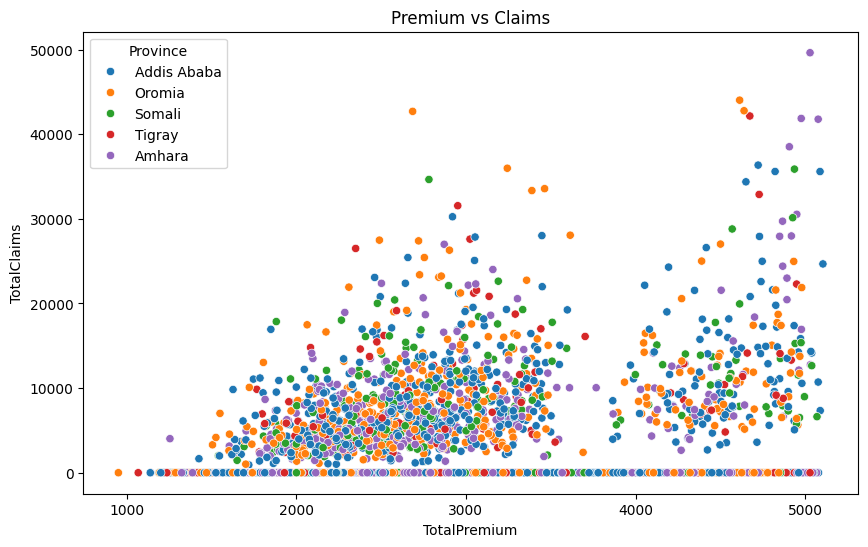

In [17]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="TotalPremium",
    y="TotalClaims",
    hue="Province"
)

plt.title("Premium vs Claims")

plt.show()